# Final Model Evaluation and Interpretation

## 1. Evaluation Objective

This notebook compares the three locked Stage 2 models without retraining or threshold adjustment. It asks whether predictions are comparable, how model ranking changes under class imbalance, which classes and records cause difficulty, how uncertain the rankings are, and what the results mean for decision-support deployment. Heartbeat classification is not patient-level diagnosis.


## 2. Setup and Paths


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import (accuracy_score, average_precision_score,
                             classification_report, confusion_matrix, auc,
                             f1_score, precision_recall_curve, roc_auc_score,
                             precision_recall_fscore_support, recall_score,
                             roc_curve)
from sklearn.preprocessing import label_binarize
from scipy.stats import binomtest
import joblib


In [2]:
RANDOM_SEED = 42
CLASS_ORDER = ["N", "S", "V", "F"]
MODEL_KEYS = ["logistic_regression", "random_forest", "cnn"]
MODEL_LABELS = {
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
    "cnn": "CNN"
}
BOOTSTRAP_RESAMPLES = 2000
CONFIDENCE_LEVEL = 0.95

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data" / "processed"
METRICS = ROOT / "results" / "metrics"
PREDICTIONS = ROOT / "results" / "predictions"
MODELS = ROOT / "results" / "models"
FIGURES = ROOT / "figures"
TABLES = ROOT / "report" / "tables"
NOTEBOOKS = ROOT / "notebooks"


## 3. Load Locked Predictions


In [3]:
lr_predictions = pd.read_csv(
    PREDICTIONS / "logistic_regression_test_predictions.csv",
    dtype={"record_id": str}
)
print("LR prediction rows:", len(lr_predictions))


LR prediction rows: 15133


In [4]:
rf_predictions = pd.read_csv(
    PREDICTIONS / "random_forest_test_predictions.csv",
    dtype={"record_id": str}
)
print("RF prediction rows:", len(rf_predictions))


RF prediction rows: 15133


In [5]:
cnn_predictions = pd.read_csv(
    PREDICTIONS / "cnn_test_predictions.csv",
    dtype={"record_id": str}
)
print("CNN prediction rows:", len(cnn_predictions))


CNN prediction rows: 15133


In [6]:
predictions = {
    "logistic_regression": lr_predictions,
    "random_forest": rf_predictions,
    "cnn": cnn_predictions
}
probability_columns = [f"probability_{label}" for label in CLASS_ORDER]
prediction_summary = pd.DataFrame([
    [MODEL_LABELS[key], len(frame), ", ".join(probability_columns)]
    for key, frame in predictions.items()
], columns=["Model", "Prediction rows", "Probability columns"])
display(prediction_summary)


,Model,Prediction rows,Probability columns
0,Logistic Regression,15133,"probability_N, probability_S, probability_V, p..."
1,Random Forest,15133,"probability_N, probability_S, probability_V, p..."
2,CNN,15133,"probability_N, probability_S, probability_V, p..."


In [7]:
reference = lr_predictions[["beat_id", "record_id", "true_class"]]
setup_table = pd.DataFrame({
    "Setting": ["Classes", "Test beats", "Test records", "Bootstrap unit",
                "Bootstrap resamples", "Confidence level", "Primary balanced metric"],
    "Value": [", ".join(CLASS_ORDER), len(reference), reference.record_id.nunique(),
              "ECG record", BOOTSTRAP_RESAMPLES, "95%", "Macro F1"]
})
display(setup_table)


,Setting,Value
0,Classes,"N, S, V, F"
1,Test beats,15133
2,Test records,8
3,Bootstrap unit,ECG record
4,Bootstrap resamples,2000
5,Confidence level,95%
6,Primary balanced metric,Macro F1


## 4. Verify Prediction Integrity


In [8]:
integrity_rows = []
for key, frame in predictions.items():
    integrity_rows.append({
        "Model": MODEL_LABELS[key],
        "Required columns present": all(
            column in frame.columns
            for column in ["true_class", "predicted_class", *probability_columns]
        ),
        "Row count correct": len(frame) == 15133,
        "Beat IDs aligned": frame.beat_id.equals(reference.beat_id),
        "True labels aligned": frame.true_class.equals(reference.true_class),
        "Probability sums valid": np.allclose(
            frame[probability_columns].sum(axis=1), 1, atol=1e-5
        )
    })
integrity_checks = pd.DataFrame(integrity_rows)
for column in integrity_checks.columns[1:]:
    integrity_checks[column] = integrity_checks[column].map({True:"PASS", False:"FAIL"})
display(integrity_checks)


,Model,Required columns present,Row count correct,Beat IDs aligned,True labels aligned,Probability sums valid
0,Logistic Regression,PASS,PASS,PASS,PASS,PASS
1,Random Forest,PASS,PASS,PASS,PASS,PASS
2,CNN,PASS,PASS,PASS,PASS,PASS


In [9]:
train_records = set((DATA / "train_records.txt").read_text().split())
validation_records = set((DATA / "validation_records.txt").read_text().split())
test_records = set((DATA / "test_records.txt").read_text().split())
assert not (train_records & validation_records)
assert not (train_records & test_records)
assert not (validation_records & test_records)
assert set(reference.record_id) == test_records

classical_test = pd.read_csv(DATA / "classical_test.csv", dtype={"record_id": str})
assert reference.beat_id.equals(classical_test.beat_id)
assert np.array_equal(reference.true_class, classical_test.mapped_class)
print("Prediction provenance and record splits verified.")


Prediction provenance and record splits verified.


In [10]:
scaler = joblib.load(MODELS / "logistic_regression_scaler.joblib")
classical_train = pd.read_csv(DATA / "classical_train.csv")
drop_columns = {"beat_id", "record_id", "annotation_sample", "annotation_symbol",
                "mapped_class", "split", "selected_lead"}
feature_columns = [column for column in classical_train if column not in drop_columns]
assert np.allclose(scaler.mean_, classical_train[feature_columns].mean().to_numpy())
assert np.allclose(scaler.var_, classical_train[feature_columns].var(ddof=0).to_numpy())
print("LR scaler matches a training-only feature fit.")


LR scaler matches a training-only feature fit.


## 5. Overall Model Comparison


In [11]:
def calculate_overall_metrics(frame):
    y_true = frame.true_class.to_numpy()
    y_pred = frame.predicted_class.to_numpy()
    probabilities = frame[probability_columns].to_numpy()
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
    )
    weighted_f1 = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_ORDER, average="weighted", zero_division=0
    )[2]
    binary_true = label_binarize(y_true, classes=CLASS_ORDER)
    class_ap = []
    for class_index in range(len(CLASS_ORDER)):
        class_ap.append(average_precision_score(binary_true[:, class_index], probabilities[:, class_index]))
    return {"accuracy":accuracy_score(y_true, y_pred), "macro_precision":precision,
            "macro_recall":recall, "macro_f1":macro_f1,
            "weighted_f1":weighted_f1, "macro_average_precision":np.mean(class_ap)}


In [12]:
overall_rows = []
for key in MODEL_KEYS:
    metrics = calculate_overall_metrics(predictions[key])
    row = {"model": key}
    row.update(metrics)
    overall_rows.append(row)
trained_model_metrics = pd.DataFrame(overall_rows)

baseline = json.loads((METRICS / "majority_baseline_validation.json").read_text())
master_rows = [{"model":"Majority baseline (validation only)",
                "accuracy":baseline["validation_accuracy"],
                "macro_f1":baseline["validation_macro_f1"]}]
master = pd.concat([pd.DataFrame(master_rows), trained_model_metrics], ignore_index=True)
master.to_csv(METRICS / "model_comparison.csv", index=False)


In [13]:
model_comparison = trained_model_metrics.copy()
model_comparison["Model"] = model_comparison.model.map(MODEL_LABELS)
model_comparison = model_comparison.rename(columns={
    "accuracy":"Accuracy", "macro_precision":"Macro Precision",
    "macro_recall":"Macro Recall", "macro_f1":"Macro F1",
    "weighted_f1":"Weighted F1", "macro_average_precision":"Macro AP"
})[["Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1", "Macro AP"]]
model_comparison.to_csv(METRICS / "report_model_comparison.csv", index=False)
display(model_comparison.round(4))


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Macro AP
0,Logistic Regression,0.6903,0.4936,0.6115,0.4555,0.7851,0.6304
1,Random Forest,0.8922,0.5044,0.5003,0.4979,0.9129,0.5152
2,CNN,0.9522,0.4836,0.4570,0.4686,0.9382,0.4710


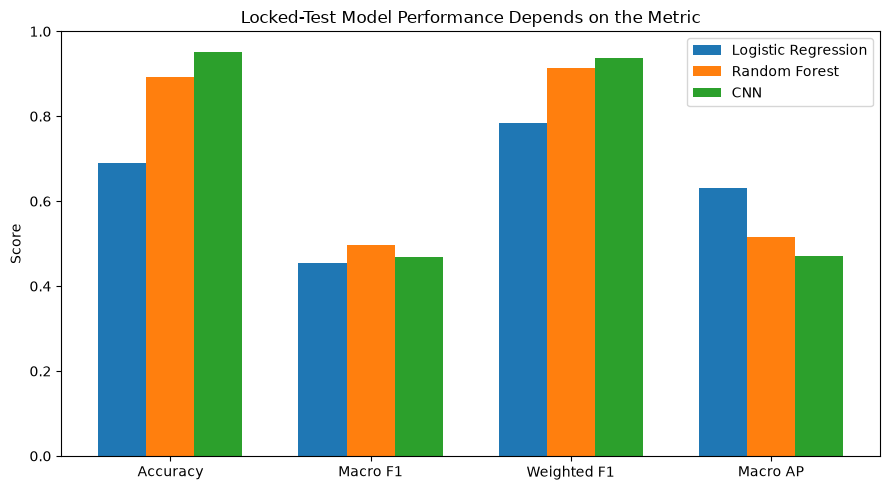

In [14]:
plot_metrics = ["Accuracy", "Macro F1", "Weighted F1", "Macro AP"]
positions = np.arange(len(plot_metrics))
width = 0.24
plt.figure(figsize=(9, 5))
for index, model_name in enumerate(model_comparison.Model):
    values = model_comparison.loc[model_comparison.Model == model_name, plot_metrics].iloc[0]
    plt.bar(positions + (index - 1) * width, values, width, label=model_name)
plt.xticks(positions, plot_metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Locked-Test Model Performance Depends on the Metric")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "evaluation_model_metric_comparison.png", dpi=200)
plt.show()


## 6. Accuracy vs Balanced Performance

Accuracy gives dominant class N substantial influence. Macro F1 gives each class equal importance, so CNN's high accuracy must be interpreted alongside its minority-class performance.


In [15]:
accuracy_vs_macro_f1 = model_comparison[["Model", "Accuracy", "Macro F1"]].copy()
accuracy_vs_macro_f1["Difference"] = (
    accuracy_vs_macro_f1["Accuracy"] - accuracy_vs_macro_f1["Macro F1"]
)
display(accuracy_vs_macro_f1.round(4))


,Model,Accuracy,Macro F1,Difference
0,Logistic Regression,0.6903,0.4555,0.2349
1,Random Forest,0.8922,0.4979,0.3942
2,CNN,0.9522,0.4686,0.4836


## 7. Per-Class Model Comparison


In [16]:
per_class_rows = []
for key in MODEL_KEYS:
    frame = predictions[key]
    y_true = frame.true_class.to_numpy()
    y_pred = frame.predicted_class.to_numpy()
    report = classification_report(
        y_true, y_pred, labels=CLASS_ORDER, output_dict=True, zero_division=0
    )
    binary_true = label_binarize(y_true, classes=CLASS_ORDER)
    for class_index, label in enumerate(CLASS_ORDER):
        predicted_support = int((y_pred == label).sum())
        average_precision = average_precision_score(
            binary_true[:, class_index], frame[f"probability_{label}"]
        )
        per_class_rows.append({"model":key, "class":label,
            "precision":report[label]["precision"] if predicted_support else np.nan,
            "recall":report[label]["recall"],
            "f1":report[label]["f1-score"] if predicted_support else np.nan,
            "support":int(report[label]["support"]),
            "predicted_support":predicted_support, "average_precision":average_precision})
per_class = pd.DataFrame(per_class_rows)
per_class.to_csv(METRICS / "per_class_comparison.csv", index=False)


In [17]:
per_class_comparison = per_class.copy()
per_class_comparison["Model"] = per_class_comparison.model.map(MODEL_LABELS)
per_class_comparison["Class"] = per_class_comparison["class"]
per_class_comparison = per_class_comparison.rename(columns={
    "precision":"Precision", "recall":"Recall", "f1":"F1",
    "support":"Support", "average_precision":"Average Precision"
})[["Model", "Class", "Precision", "Recall", "F1", "Support", "Average Precision"]]
display(per_class_comparison.round(4))


,Model,Class,Precision,Recall,F1,Support,Average Precision
0,Logistic Regression,N,0.9862,0.6768,0.8027,13374,0.9654
1,Logistic Regression,S,0.1137,0.9309,0.2027,434,0.7263
2,Logistic Regression,V,0.8729,0.7614,0.8133,1299,0.8284
3,Logistic Regression,F,0.0016,0.0769,0.0031,26,0.0015
4,Random Forest,N,0.9630,0.9154,0.9386,13374,0.9872
5,Random Forest,S,0.1182,0.1198,0.1190,434,0.0901
6,Random Forest,V,0.9348,0.9276,0.9312,1299,0.9802
7,Random Forest,F,0.0014,0.0385,0.0028,26,0.0034
8,CNN,N,0.9526,0.9967,0.9741,13374,0.9033
9,CNN,S,0.0000,0.0000,0.0000,434,0.0174


In [18]:
def plot_class_metric(metric, title, file_name):
    positions = np.arange(len(CLASS_ORDER))
    width = 0.24
    plt.figure(figsize=(8, 4.5))
    for index, key in enumerate(MODEL_KEYS):
        values = per_class[per_class.model == key].set_index("class").loc[CLASS_ORDER, metric]
        plt.bar(positions + (index - 1) * width, values, width, label=MODEL_LABELS[key])
    plt.xticks(positions, CLASS_ORDER)
    plt.xlabel("Heartbeat class")
    plt.ylabel(metric.replace("_", " ").title())
    plt.ylim(0, 1)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / file_name, dpi=200)
    plt.show()


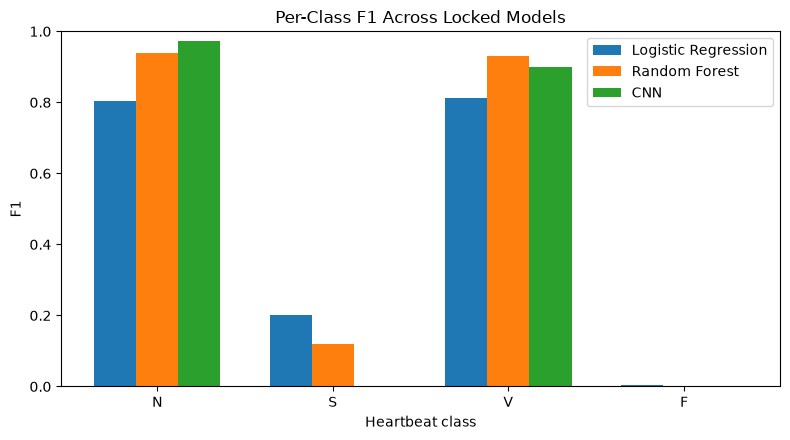

In [19]:
plot_class_metric(
    "f1", "Per-Class F1 Across Locked Models", "evaluation_per_class_f1.png"
)


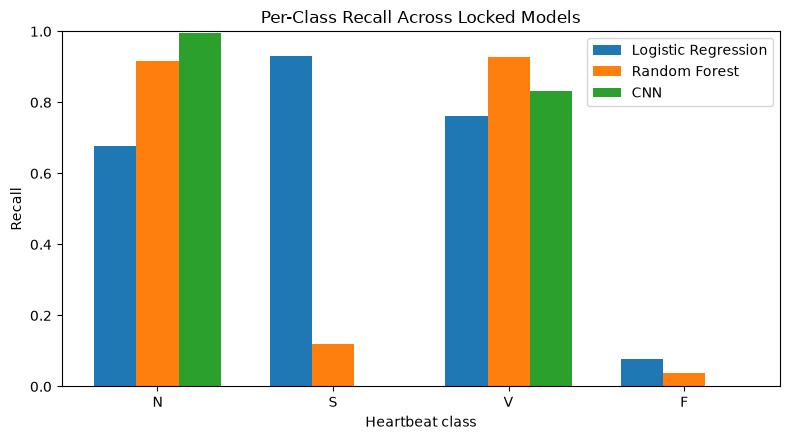

In [20]:
plot_class_metric(
    "recall", "Per-Class Recall Across Locked Models", "evaluation_per_class_recall.png"
)


## 8. Confusion Matrices


In [21]:
def make_confusion_table(frame):
    matrix = confusion_matrix(
        frame.true_class, frame.predicted_class, labels=CLASS_ORDER
    )
    table = pd.DataFrame(matrix, columns=CLASS_ORDER)
    table.insert(0, "Actual / Predicted", CLASS_ORDER)
    return matrix, table


In [22]:
lr_confusion, lr_confusion_table = make_confusion_table(lr_predictions)
display(lr_confusion_table)


,Actual / Predicted,N,S,V,F
0,N,9052,2930,130,1262
1,S,18,404,12,0
2,V,104,202,989,4
3,F,5,17,2,2


In [23]:
rf_confusion, rf_confusion_table = make_confusion_table(rf_predictions)
display(rf_confusion_table)


,Actual / Predicted,N,S,V,F
0,N,12243,375,66,690
1,S,371,52,11,0
2,V,81,13,1205,0
3,F,18,0,7,1


In [24]:
cnn_confusion, cnn_confusion_table = make_confusion_table(cnn_predictions)
display(cnn_confusion_table)

confusion_matrices = {
    "logistic_regression": lr_confusion,
    "random_forest": rf_confusion,
    "cnn": cnn_confusion
}


,Actual / Predicted,N,S,V,F
0,N,13330,27,13,4
1,S,433,0,1,0
2,V,213,6,1080,0
3,F,18,2,6,0


In [25]:
def plot_canonical_confusion(matrix, model_name, file_name):
    normalised = np.divide(matrix, matrix.sum(axis=1, keepdims=True),
                           out=np.zeros_like(matrix, dtype=float),
                           where=matrix.sum(axis=1, keepdims=True) != 0)
    figure, axes = plt.subplots(1, 2, figsize=(10, 4))
    for axis, values, title, value_format in [
        (axes[0], matrix, "Counts", "d"),
        (axes[1], normalised, "Row-normalised", ".1%")]:
        axis.imshow(values, cmap="Blues", vmin=0)
        axis.set(xticks=range(4), yticks=range(4), xticklabels=CLASS_ORDER,
                 yticklabels=CLASS_ORDER, xlabel="Predicted class",
                 ylabel="True class", title=title)
        for row in range(4):
            for column in range(4):
                color = "white" if values[row, column] > values.max() / 2 else "black"
                axis.text(column, row, format(values[row, column], value_format),
                          ha="center", va="center", color=color)
    figure.suptitle(f"{model_name} confusion matrix")
    figure.tight_layout()
    figure.savefig(FIGURES / file_name, dpi=220)
    plt.show()


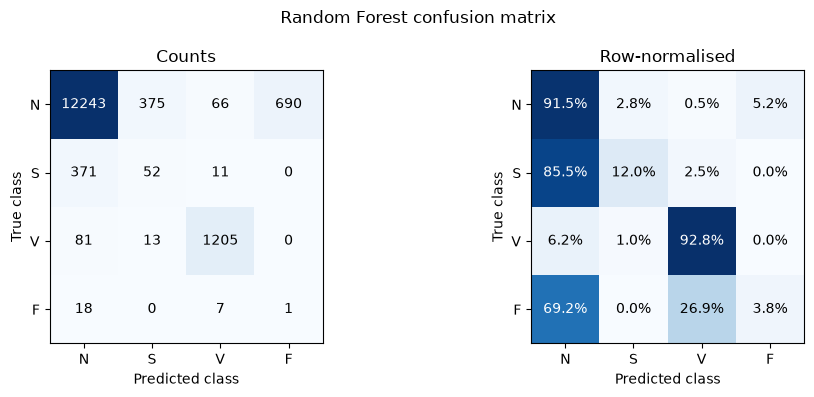

In [26]:
plot_canonical_confusion(
    rf_confusion, "Random Forest", "figure_05_rf_confusion_matrix.png"
)


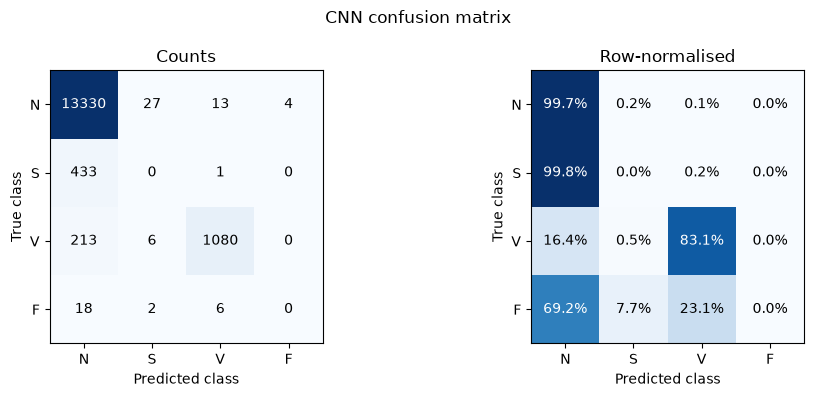

In [27]:
plot_canonical_confusion(
    cnn_confusion, "CNN", "figure_06_cnn_confusion_matrix.png"
)


## 9. Important Misclassification Patterns


In [28]:
direction_rows = []
for key, matrix in confusion_matrices.items():
    abnormal_to_normal = int(matrix[1:, 0].sum())
    normal_to_abnormal = int(matrix[0, 1:].sum())
    direction_rows.append([
        MODEL_LABELS[key], abnormal_to_normal, normal_to_abnormal
    ])
error_direction_summary = pd.DataFrame(
    direction_rows, columns=["Model", "Abnormal → N", "N → Abnormal"]
)
display(error_direction_summary)


,Model,Abnormal → N,N → Abnormal
0,Logistic Regression,127,4322
1,Random Forest,470,1131
2,CNN,664,44


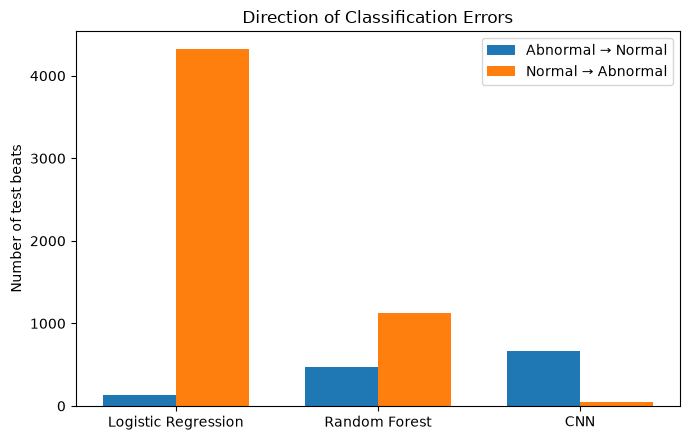

In [29]:
positions = np.arange(len(error_direction_summary))
plt.figure(figsize=(7, 4.5))
plt.bar(positions - 0.18, error_direction_summary["Abnormal → N"], 0.36,
        label="Abnormal → Normal")
plt.bar(positions + 0.18, error_direction_summary["N → Abnormal"], 0.36,
        label="Normal → Abnormal")
plt.xticks(positions, error_direction_summary.Model)
plt.ylabel("Number of test beats")
plt.title("Direction of Classification Errors")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "evaluation_error_direction.png", dpi=200)
plt.show()


In [30]:
misclassification_rows = []
for key, matrix in confusion_matrices.items():
    for true_index, true_label in enumerate(CLASS_ORDER):
        for predicted_index, predicted_label in enumerate(CLASS_ORDER):
            if true_index != predicted_index:
                misclassification_rows.append([
                    MODEL_LABELS[key], true_label, predicted_label,
                    int(matrix[true_index, predicted_index])
                ])
top_misclassification_pairs = pd.DataFrame(
    misclassification_rows,
    columns=["Model", "True Class", "Predicted Class", "Count"]
)
top_misclassification_pairs = top_misclassification_pairs.sort_values(
    ["Model", "Count"], ascending=[True, False]
)
display(top_misclassification_pairs.groupby("Model").head(6))


,Model,True Class,Predicted Class,Count
27,CNN,S,N,433
30,CNN,V,N,213
24,CNN,N,S,27
33,CNN,F,N,18
25,CNN,N,V,13
31,CNN,V,S,6
0,Logistic Regression,N,S,2930
2,Logistic Regression,N,F,1262
7,Logistic Regression,V,S,202
1,Logistic Regression,N,V,130


## 10. Precision–Recall and Average Precision


In [31]:
average_precision_table = per_class_comparison[
    ["Model", "Class", "Average Precision"]
].copy()
display(average_precision_table.round(4))


,Model,Class,Average Precision
0,Logistic Regression,N,0.9654
1,Logistic Regression,S,0.7263
2,Logistic Regression,V,0.8284
3,Logistic Regression,F,0.0015
4,Random Forest,N,0.9872
5,Random Forest,S,0.0901
6,Random Forest,V,0.9802
7,Random Forest,F,0.0034
8,CNN,N,0.9033
9,CNN,S,0.0174


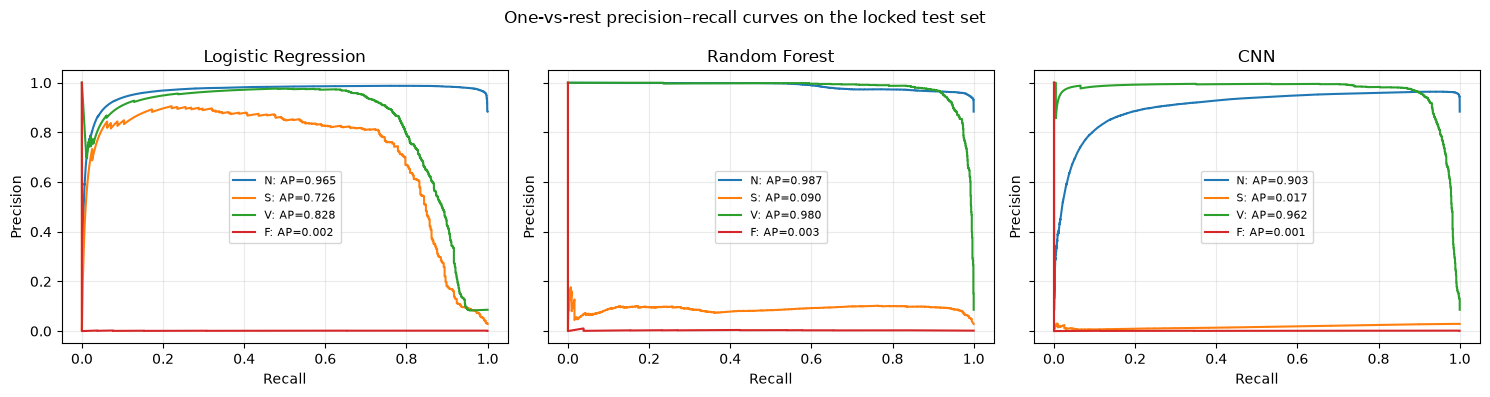

In [32]:
figure, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for axis, key in zip(axes, MODEL_KEYS):
    frame = predictions[key]
    binary_true = label_binarize(frame.true_class, classes=CLASS_ORDER)
    for class_index, label in enumerate(CLASS_ORDER):
        scores = frame[f"probability_{label}"].to_numpy()
        precision, recall, _ = precision_recall_curve(binary_true[:, class_index], scores)
        ap = average_precision_score(binary_true[:, class_index], scores)
        axis.plot(recall, precision, label=f"{label}: AP={ap:.3f}")
    axis.set(xlabel="Recall", ylabel="Precision", title=MODEL_LABELS[key])
    axis.legend(fontsize=8)
    axis.grid(alpha=0.25)
figure.suptitle("One-vs-rest precision–recall curves on the locked test set")
figure.tight_layout()
figure.savefig(FIGURES / "figure_07_precision_recall.png", dpi=220)
plt.show()


## 11. Average Precision vs Class Prevalence


In [33]:
support = per_class[per_class.model == "logistic_regression"].set_index("class").support
support = support.reindex(CLASS_ORDER).astype(int)
total_test_beats = int(support.sum())
ap_prevalence_rows = []
for label in CLASS_ORDER:
    prevalence = support[label] / total_test_beats
    row = {"class":label, "test_support":int(support[label]),
           "test_prevalence":prevalence, "no_skill_ap_baseline":prevalence}
    for key, prefix in [("logistic_regression","lr"),
                        ("random_forest","rf"), ("cnn","cnn")]:
        value = per_class[(per_class.model == key) & (per_class["class"] == label)]
        row[f"{prefix}_ap"] = float(value.average_precision.iloc[0])
    ap_prevalence_rows.append(row)
ap_prevalence = pd.DataFrame(ap_prevalence_rows)
ap_prevalence.to_csv(METRICS / "per_class_average_precision.csv", index=False)
display(ap_prevalence)


,class,test_support,test_prevalence,no_skill_ap_baseline,lr_ap,rf_ap,cnn_ap
0,N,13374,0.883764,0.883764,0.965385,0.987207,0.903305
1,S,434,0.028679,0.028679,0.726255,0.090131,0.017436
2,V,1299,0.085839,0.085839,0.828378,0.980228,0.961894
3,F,26,0.001718,0.001718,0.001518,0.003369,0.001346


In [34]:
report_per_class = per_class.copy()
report_per_class["Model"] = report_per_class.model.map(MODEL_LABELS)
report_per_class["Class"] = report_per_class["class"]
report_per_class["Prevalence Baseline"] = report_per_class.Class.map(
    ap_prevalence.set_index("class").test_prevalence
)
report_per_class = report_per_class.rename(columns={
    "support":"Support", "precision":"Precision", "recall":"Recall",
    "f1":"F1", "average_precision":"Average Precision"
})[["Model", "Class", "Support", "Precision", "Recall", "F1",
    "Average Precision", "Prevalence Baseline"]]
report_per_class.to_csv(METRICS / "report_per_class_summary.csv", index=False)


In [35]:
ap_baseline_rows = []
for _, row in ap_prevalence.iterrows():
    for model_name, column in [("Logistic Regression","lr_ap"),
                               ("Random Forest","rf_ap"), ("CNN","cnn_ap")]:
        ap_value = row[column]
        ap_baseline_rows.append([
            model_name, row["class"], ap_value, row.test_prevalence,
            ap_value / row.test_prevalence
        ])
ap_baseline_ratio = pd.DataFrame(
    ap_baseline_rows,
    columns=["Model", "Class", "AP", "Prevalence Baseline", "AP / Baseline"]
)
display(ap_baseline_ratio.round(4))


,Model,Class,AP,Prevalence Baseline,AP / Baseline
0,Logistic Regression,N,0.9654,0.8838,1.0924
1,Random Forest,N,0.9872,0.8838,1.1170
2,CNN,N,0.9033,0.8838,1.0221
3,Logistic Regression,S,0.7263,0.0287,25.3235
4,Random Forest,S,0.0901,0.0287,3.1427
5,CNN,S,0.0174,0.0287,0.6080
6,Logistic Regression,V,0.8284,0.0858,9.6504
7,Random Forest,V,0.9802,0.0858,11.4194
8,CNN,V,0.9619,0.0858,11.2058
9,Logistic Regression,F,0.0015,0.0017,0.8837


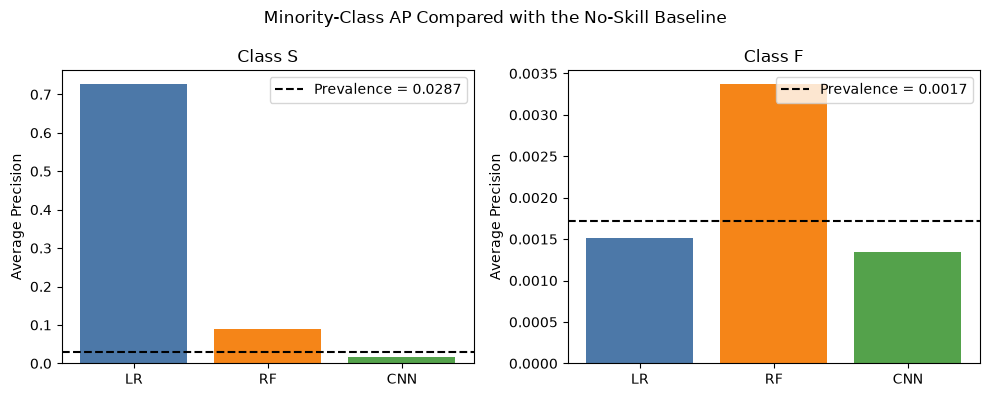

In [36]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, label in zip(axes, ["S", "F"]):
    row = ap_prevalence.set_index("class").loc[label]
    values = [row.lr_ap, row.rf_ap, row.cnn_ap]
    axis.bar(["LR", "RF", "CNN"], values, color=["#4C78A8", "#F58518", "#54A24B"])
    axis.axhline(row.test_prevalence, color="black", linestyle="--",
                 label=f"Prevalence = {row.test_prevalence:.4f}")
    axis.set(title=f"Class {label}", ylabel="Average Precision")
    axis.legend()
figure.suptitle("Minority-Class AP Compared with the No-Skill Baseline")
figure.tight_layout()
figure.savefig(FIGURES / "evaluation_ap_vs_prevalence.png", dpi=200)
plt.show()


S shows a large LR ranking advantage above prevalence despite low fixed-threshold precision. F AP remains close to its extremely small prevalence baseline for every model, so reliable F ranking is not demonstrated.


## ROC Analysis

ROC analysis evaluates how well each model separates one class from the remaining classes across different classification thresholds. Because this is a multiclass problem, a one-vs-rest approach is used for N, S, V and F. ROC-AUC is reported together with Precision-Recall results because ROC-AUC can appear optimistic for highly imbalanced classes.


### 1. Load and verify prediction probabilities


In [37]:
roc_lr_predictions = pd.read_csv(
    PREDICTIONS / "logistic_regression_test_predictions.csv",
    dtype={"record_id": str}
)
roc_rf_predictions = pd.read_csv(
    PREDICTIONS / "random_forest_test_predictions.csv",
    dtype={"record_id": str}
)
roc_cnn_predictions = pd.read_csv(
    PREDICTIONS / "cnn_test_predictions.csv",
    dtype={"record_id": str}
)

roc_predictions = {
    "logistic_regression": roc_lr_predictions,
    "random_forest": roc_rf_predictions,
    "cnn": roc_cnn_predictions
}


In [38]:
roc_reference = roc_lr_predictions[["beat_id", "true_class"]]
roc_verification_rows = []

for key in MODEL_KEYS:
    frame = roc_predictions[key]
    columns_present = all(column in frame for column in probability_columns)
    probabilities = frame[probability_columns].to_numpy()
    probability_ok = (
        columns_present
        and np.isfinite(probabilities).all()
        and np.allclose(probabilities.sum(axis=1), 1, atol=1e-5)
    )
    alignment_ok = (
        len(frame) == len(roc_reference)
        and frame.beat_id.equals(roc_reference.beat_id)
        and frame.true_class.equals(roc_reference.true_class)
        and set(frame.true_class.unique()) == set(CLASS_ORDER)
    )
    roc_verification_rows.append({
        "Model": MODEL_LABELS[key],
        "Test beats": len(frame),
        "Classes": ", ".join(CLASS_ORDER),
        "Probability check": "PASS" if probability_ok else "FAIL",
        "Alignment check": "PASS" if alignment_ok else "FAIL"
    })

roc_verification = pd.DataFrame(roc_verification_rows)
assert roc_verification.iloc[:, 3:].eq("PASS").all().all()
display(roc_verification)


,Model,Test beats,Classes,Probability check,Alignment check
0,Logistic Regression,15133,"N, S, V, F",PASS,PASS
1,Random Forest,15133,"N, S, V, F",PASS,PASS
2,CNN,15133,"N, S, V, F",PASS,PASS


### 2. Prepare one-vs-rest labels

For ROC analysis, each heartbeat class is temporarily treated as the positive class while the remaining three classes are treated as negative.


In [39]:
CLASS_ORDER = ["N", "S", "V", "F"]
roc_binary_true = label_binarize(
    roc_reference["true_class"],
    classes=CLASS_ORDER
)

roc_support = pd.DataFrame({
    "Class": CLASS_ORDER,
    "Positive test beats": roc_binary_true.sum(axis=0).astype(int),
    "Negative test beats": (len(roc_binary_true) - roc_binary_true.sum(axis=0)).astype(int),
    "Prevalence": roc_binary_true.mean(axis=0)
})

expected_support = np.array([13374, 434, 1299, 26])
assert np.array_equal(roc_support["Positive test beats"], expected_support)
assert int(roc_support["Positive test beats"].sum()) == 15133
display(roc_support.round({"Prevalence": 4}))


,Class,Positive test beats,Negative test beats,Prevalence
0,N,13374,1759,0.8838
1,S,434,14699,0.0287
2,V,1299,13834,0.0858
3,F,26,15107,0.0017


### 3. Calculate ROC curves


Logistic Regression is calculated first. Each class probability is compared with its matching one-vs-rest true label.


In [40]:
lr_roc = {}

for class_index, class_name in enumerate(CLASS_ORDER):
    true_binary = roc_binary_true[:, class_index]
    class_probability = roc_lr_predictions[
        f"probability_{class_name}"
    ].to_numpy()
    fpr, tpr, thresholds = roc_curve(
        true_binary,
        class_probability
    )
    lr_roc[class_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": auc(fpr, tpr)
    }

print("Logistic Regression ROC curves calculated.")


Logistic Regression ROC curves calculated.


The same one-vs-rest calculation is repeated for Random Forest.


In [41]:
rf_roc = {}

for class_index, class_name in enumerate(CLASS_ORDER):
    true_binary = roc_binary_true[:, class_index]
    class_probability = roc_rf_predictions[
        f"probability_{class_name}"
    ].to_numpy()
    fpr, tpr, thresholds = roc_curve(
        true_binary,
        class_probability
    )
    rf_roc[class_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": auc(fpr, tpr)
    }

print("Random Forest ROC curves calculated.")


Random Forest ROC curves calculated.


Finally, the same calculation is applied to the CNN probabilities.


In [42]:
cnn_roc = {}

for class_index, class_name in enumerate(CLASS_ORDER):
    true_binary = roc_binary_true[:, class_index]
    class_probability = roc_cnn_predictions[
        f"probability_{class_name}"
    ].to_numpy()
    fpr, tpr, thresholds = roc_curve(
        true_binary,
        class_probability
    )
    cnn_roc[class_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": auc(fpr, tpr)
    }

print("CNN ROC curves calculated.")


CNN ROC curves calculated.


### 4. Per-class ROC-AUC


In [43]:
roc_results = {
    "logistic_regression": lr_roc,
    "random_forest": rf_roc,
    "cnn": cnn_roc
}
roc_auc_rows = []
roc_per_class_rows = []

for key in MODEL_KEYS:
    probabilities = roc_predictions[key][probability_columns].to_numpy()
    row = {"Model": MODEL_LABELS[key]}
    for class_name in CLASS_ORDER:
        row[class_name] = roc_results[key][class_name]["auc"]
        roc_per_class_rows.append({
            "Model": MODEL_LABELS[key],
            "Class": class_name,
            "Positive Support": int(
                roc_support.set_index("Class").loc[class_name, "Positive test beats"]
            ),
            "Negative Support": int(
                roc_support.set_index("Class").loc[class_name, "Negative test beats"]
            ),
            "ROC AUC": roc_results[key][class_name]["auc"]
        })
    row["Macro ROC-AUC"] = roc_auc_score(
        roc_binary_true, probabilities, average="macro", multi_class="ovr"
    )
    row["Weighted ROC-AUC"] = roc_auc_score(
        roc_binary_true, probabilities, average="weighted", multi_class="ovr"
    )
    micro_fpr, micro_tpr, _ = roc_curve(
        roc_binary_true.ravel(), probabilities.ravel()
    )
    row["Micro ROC-AUC"] = auc(micro_fpr, micro_tpr)
    roc_auc_rows.append(row)

roc_auc_table = pd.DataFrame(roc_auc_rows)
roc_auc_per_class = pd.DataFrame(roc_per_class_rows)
display(roc_auc_table.round(4))


,Model,N,S,V,F,Macro ROC-AUC,Weighted ROC-AUC,Micro ROC-AUC
0,Logistic Regression,0.9269,0.9625,0.9244,0.4108,0.8062,0.9269,0.9224
1,Random Forest,0.9200,0.8479,0.9970,0.6923,0.8643,0.9241,0.9868
2,CNN,0.7703,0.2254,0.9914,0.3864,0.5934,0.7730,0.9769


In [44]:
roc_auc_per_class.to_csv(
    METRICS / "roc_auc_per_class.csv",
    index=False
)
roc_auc_model_comparison = roc_auc_table[
    ["Model", "N", "S", "V", "F"]
].copy()
roc_auc_model_comparison.to_csv(
    METRICS / "roc_auc_model_comparison.csv",
    index=False
)

macro_roc_lookup = roc_auc_table.set_index("Model")["Macro ROC-AUC"]
model_comparison["Macro ROC AUC"] = model_comparison["Model"].map(macro_roc_lookup)
model_comparison.to_csv(METRICS / "report_model_comparison.csv", index=False)
print("Full-precision ROC metric CSV files saved.")


Full-precision ROC metric CSV files saved.


### 5. ROC curves by model


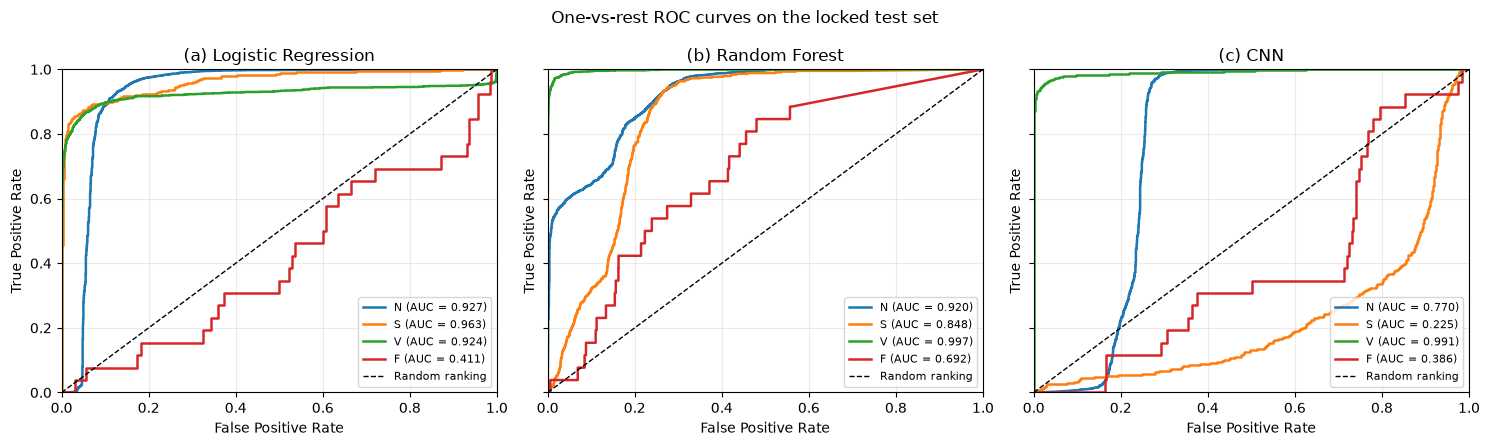

In [45]:
figure, axes = plt.subplots(
    1, 3, figsize=(15, 4.5), sharex=True, sharey=True
)
panel_titles = [
    "(a) Logistic Regression",
    "(b) Random Forest",
    "(c) CNN"
]

for axis, key, title in zip(axes, MODEL_KEYS, panel_titles):
    for class_name in CLASS_ORDER:
        result = roc_results[key][class_name]
        axis.plot(
            result["fpr"],
            result["tpr"],
            linewidth=1.8,
            label=f'{class_name} (AUC = {result["auc"]:.3f})'
        )
    axis.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random ranking")
    axis.set(
        title=title,
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        xlim=(0, 1),
        ylim=(0, 1)
    )
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8, loc="lower right")

figure.suptitle("One-vs-rest ROC curves on the locked test set")
figure.tight_layout()
figure.savefig(
    FIGURES / "evaluation_roc_curves.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()


### 6. ROC-AUC comparison across models


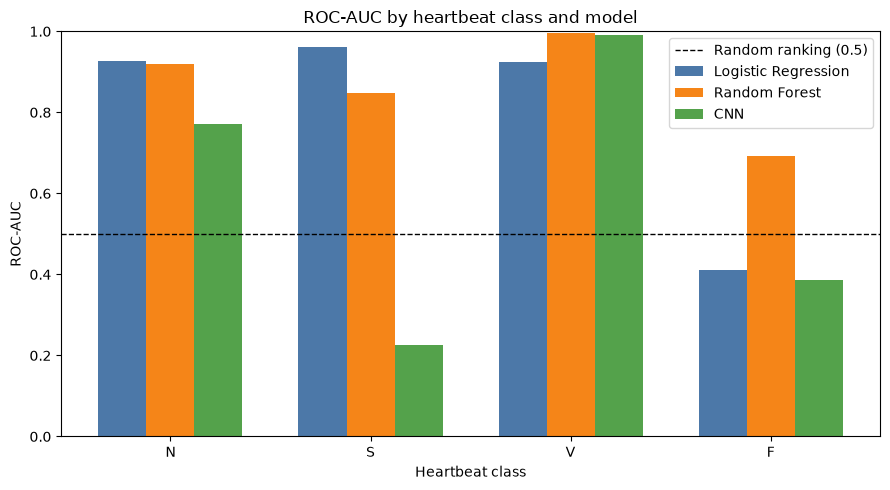

In [46]:
positions = np.arange(len(CLASS_ORDER))
width = 0.24
colors = ["#4C78A8", "#F58518", "#54A24B"]

plt.figure(figsize=(9, 5))
for model_index, key in enumerate(MODEL_KEYS):
    values = [roc_results[key][label]["auc"] for label in CLASS_ORDER]
    plt.bar(
        positions + (model_index - 1) * width,
        values,
        width,
        label=MODEL_LABELS[key],
        color=colors[model_index]
    )

plt.axhline(0.5, color="black", linestyle="--", linewidth=1,
            label="Random ranking (0.5)")
plt.xticks(positions, CLASS_ORDER)
plt.xlabel("Heartbeat class")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.title("ROC-AUC by heartbeat class and model")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURES / "evaluation_roc_auc_by_class.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()


### 7. ROC-AUC compared with Average Precision


In [47]:
roc_vs_pr = report_per_class.merge(
    roc_auc_per_class[["Model", "Class", "ROC AUC"]],
    on=["Model", "Class"],
    how="left"
).rename(columns={"Prevalence Baseline": "Prevalence"})[
    ["Model", "Class", "Support", "Prevalence", "ROC AUC",
     "Average Precision", "Precision", "Recall", "F1"]
]

roc_vs_pr.to_csv(
    METRICS / "roc_vs_pr_comparison.csv",
    index=False
)
display(roc_vs_pr.round(4))


,Model,Class,Support,Prevalence,ROC AUC,Average Precision,Precision,Recall,F1
0,Logistic Regression,N,13374,0.8838,0.9269,0.9654,0.9862,0.6768,0.8027
1,Logistic Regression,S,434,0.0287,0.9625,0.7263,0.1137,0.9309,0.2027
2,Logistic Regression,V,1299,0.0858,0.9244,0.8284,0.8729,0.7614,0.8133
3,Logistic Regression,F,26,0.0017,0.4108,0.0015,0.0016,0.0769,0.0031
4,Random Forest,N,13374,0.8838,0.9200,0.9872,0.9630,0.9154,0.9386
5,Random Forest,S,434,0.0287,0.8479,0.0901,0.1182,0.1198,0.1190
6,Random Forest,V,1299,0.0858,0.9970,0.9802,0.9348,0.9276,0.9312
7,Random Forest,F,26,0.0017,0.6923,0.0034,0.0014,0.0385,0.0028
8,CNN,N,13374,0.8838,0.7703,0.9033,0.9526,0.9967,0.9741
9,CNN,S,434,0.0287,0.2254,0.0174,0.0000,0.0000,0.0000


### 8. Logistic Regression ROC interpretation

Logistic Regression shows strong ranking for N (ROC-AUC 0.9269), very strong ranking for S (0.9625), and strong ranking for V (0.9244), but poor F discrimination (0.4108). For S, the ROC-AUC and Average Precision of 0.7263 both show useful ranking ability. This does not mean that hard S classification is excellent: S recall is high at 0.9309, but precision is only 0.1137. The fixed multiclass decision rule is therefore overinclusive even though the probability ranking is informative.


### 9. Random Forest ROC interpretation

Random Forest records ROC-AUC values of 0.9200 for N, 0.8479 for S, 0.9970 for V and 0.6923 for F. Its V ranking is exceptionally strong on this locked test set. Although Random Forest achieved a higher ROC-AUC for F than the other models, this should not be interpreted as strong F classification. F contains only 26 test beats (prevalence 0.0017), while its Average Precision is 0.0034 and F1 is 0.0028. The result is also uncertain because the test set contains only eight held-out ECG records.


### 10. CNN ROC interpretation

The CNN shows strong V ranking (ROC-AUC 0.9914), but weaker N ranking than LR and RF (0.7703), poor S ranking (0.2254), and poor F ranking (0.3864). These ranking results agree with the existing hard-classification limitation: The CNN achieved 0% recall for both S and F: none of the true S or F test beats were correctly classified.


### 11. Cross-model ROC comparison


In [48]:
qualification = {
    "N": "Dominant class; interpret with balanced metrics.",
    "S": "High ranking ability does not translate into high precision.",
    "V": "Strong ranking is supported by strong AP and F1.",
    "F": "Very small support and near-baseline AP make ROC-AUC alone misleading."
}
best_roc_rows = []

for class_name in CLASS_ORDER:
    class_rows = roc_auc_per_class[
        roc_auc_per_class["Class"] == class_name
    ]
    best_row = class_rows.loc[class_rows["ROC AUC"].idxmax()]
    best_roc_rows.append({
        "Class": class_name,
        "Best ROC-AUC model": best_row["Model"],
        "Best ROC-AUC": best_row["ROC AUC"],
        "Important qualification": qualification[class_name]
    })

best_roc_comparison = pd.DataFrame(best_roc_rows)
display(best_roc_comparison.round({"Best ROC-AUC": 4}))


,Class,Best ROC-AUC model,Best ROC-AUC,Important qualification
0,N,Logistic Regression,0.9269,Dominant class; interpret with balanced metrics.
1,S,Logistic Regression,0.9625,High ranking ability does not translate into h...
2,V,Random Forest,0.9970,Strong ranking is supported by strong AP and F1.
3,F,Random Forest,0.6923,Very small support and near-baseline AP make R...


### 12. Overall ROC-AUC comparison


In [49]:
overall_roc_comparison = model_comparison[
    ["Model", "Macro ROC AUC", "Macro AP", "Macro F1", "Accuracy"]
].copy()
display(overall_roc_comparison.round(4))


,Model,Macro ROC AUC,Macro AP,Macro F1,Accuracy
0,Logistic Regression,0.8062,0.6304,0.4555,0.6903
1,Random Forest,0.8643,0.5152,0.4979,0.8922
2,CNN,0.5934,0.4710,0.4686,0.9522


Random Forest has the highest macro ROC-AUC and macro F1, while Logistic Regression has the highest macro AP. The CNN has the highest accuracy but substantially weaker macro ROC-AUC, macro AP and macro F1. These different rankings reinforce the existing conclusion that accuracy alone is insufficient for this imbalanced heartbeat-classification problem. ROC-AUC is not used alone to select a final model.


### 13. Why ROC and Precision-Recall differ

ROC curves compare true-positive rate with false-positive rate across thresholds. Precision-Recall curves instead compare precision with recall. When a class is extremely rare, the large number of negative examples can keep the false-positive rate numerically small even when false positives greatly outnumber the few true positives. This is especially important for F, which has only 26 test beats.

Average Precision is therefore more informative for rare-class performance, while ROC-AUC remains a useful complementary measure of ranking separation. Neither measure replaces per-class precision, recall, F1 or the confusion matrix. The 15,133 test beats also come from only eight held-out ECG records, so they must not be treated as independent patients and no unclustered AUC significance test is performed.


## 13. Validation vs Test Generalisation


In [50]:
validation_test_rows = []
metric_files = [("Logistic Regression", "logistic_regression_metrics.json"),
                ("Random Forest", "random_forest_metrics.json"),
                ("CNN", "cnn_metrics.json")]
for model_name, file_name in metric_files:
    saved = json.loads((METRICS / file_name).read_text())
    validation_test_rows.append({
        "Model":model_name,
        "Validation Accuracy":saved["validation"]["accuracy"],
        "Test Accuracy":saved["test"]["accuracy"],
        "Validation Macro F1":saved["validation"]["macro_f1"],
        "Test Macro F1":saved["test"]["macro_f1"],
        "Macro F1 Change":saved["test"]["macro_f1"] - saved["validation"]["macro_f1"]
    })
validation_test = pd.DataFrame(validation_test_rows)
validation_test.to_csv(METRICS / "validation_test_comparison.csv", index=False)
display(validation_test.round(4))


,Model,Validation Accuracy,Test Accuracy,Validation Macro F1,Test Macro F1,Macro F1 Change
0,Logistic Regression,0.8109,0.6903,0.5662,0.4555,-0.1108
1,Random Forest,0.9165,0.8922,0.6166,0.4979,-0.1187
2,CNN,0.9440,0.9522,0.4749,0.4686,-0.0062


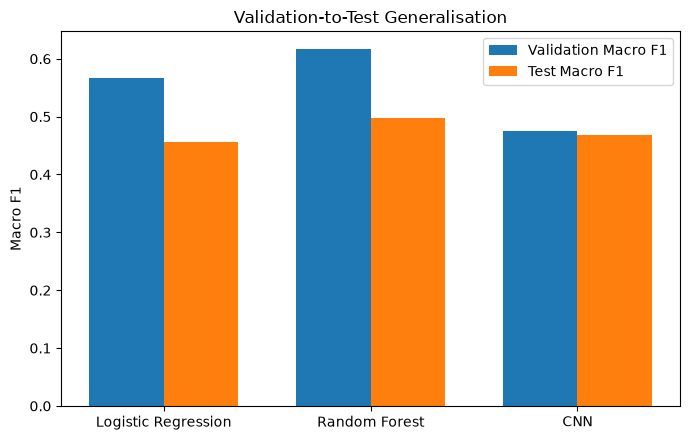

In [51]:
positions = np.arange(len(validation_test))
plt.figure(figsize=(7, 4.5))
plt.bar(positions - 0.18, validation_test["Validation Macro F1"], 0.36,
        label="Validation Macro F1")
plt.bar(positions + 0.18, validation_test["Test Macro F1"], 0.36,
        label="Test Macro F1")
plt.xticks(positions, validation_test.Model)
plt.ylabel("Macro F1")
plt.title("Validation-to-Test Generalisation")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "evaluation_validation_vs_test_macro_f1.png", dpi=200)
plt.show()


In [52]:
split_counts = {
    "S": [2037, 310, 434],
    "F": [409, 367, 26]
}
s_f_limitations = pd.DataFrame({
    "Class":["S", "F"],
    "Train":[split_counts["S"][0], split_counts["F"][0]],
    "Validation":[split_counts["S"][1], split_counts["F"][1]],
    "Test":[split_counts["S"][2], split_counts["F"][2]],
    "Main Challenge":["Separability/inter-record generalisation",
                      "Extreme scarcity and record concentration"]
})
display(s_f_limitations)


,Class,Train,Validation,Test,Main Challenge
0,S,2037,310,434,Separability/inter-record generalisation
1,F,409,367,26,Extreme scarcity and record concentration


Validation contains 367 F beats while test contains 26. F morphology is heavily record-concentrated, including records 208 and 213. This composition difference plausibly explains part of the validation-to-test decline, but does not prove a single causal explanation. S and F are different problems: S is less scarce and instead exposes separability and inter-record generalisation limits.


## 14. Per-Record Performance


In [53]:
record_rows = []
for key, frame in predictions.items():
    for record_id, group in frame.groupby("record_id", sort=True):
        present_classes = [label for label in CLASS_ORDER if (group.true_class == label).any()]
        row = {"model":key, "record_id":record_id, "n_beats":len(group),
               "accuracy":accuracy_score(group.true_class, group.predicted_class),
               "macro_f1_present_classes":f1_score(
                   group.true_class, group.predicted_class, labels=present_classes,
                   average="macro", zero_division=0)}
        for label in ["S", "V", "F"]:
            if (group.true_class == label).any():
                row[f"recall_{label}"] = recall_score(
                    group.true_class, group.predicted_class,
                    labels=[label], average=None, zero_division=0
                )[0]
            else:
                row[f"recall_{label}"] = np.nan
        record_rows.append(row)
per_record = pd.DataFrame(record_rows)
per_record.to_csv(METRICS / "per_record_performance.csv", index=False)
display(per_record)


,model,record_id,n_beats,accuracy,macro_f1_present_classes,recall_S,recall_V,recall_F
0,logistic_regression,101,1862,0.996778,0.832526,0.666667,NaN,NaN
1,logistic_regression,102,103,0.786408,0.481227,NaN,0.250000,NaN
2,logistic_regression,114,1879,0.981905,0.484084,0.416667,0.534884,0.000000
3,logistic_regression,209,3004,0.183089,0.452352,1.000000,1.000000,NaN
4,logistic_regression,210,2648,0.759063,0.507652,0.590909,0.871795,0.000000
5,logistic_regression,217,406,0.647783,0.641979,NaN,0.419753,NaN
6,logistic_regression,219,2154,0.960074,0.434122,0.000000,0.843750,0.000000
7,logistic_regression,233,3077,0.576536,0.388932,0.142857,0.809639,0.181818
8,random_forest,101,1862,0.999463,0.899866,0.666667,NaN,NaN
9,random_forest,102,103,0.990291,0.926059,NaN,0.750000,NaN


## 15. Record-Level Stability


In [54]:
record_stability = per_record.groupby("model").agg(
    accuracy_median=("accuracy", "median"), accuracy_min=("accuracy", "min"),
    accuracy_q1=("accuracy", lambda values: values.quantile(0.25)),
    accuracy_q3=("accuracy", lambda values: values.quantile(0.75)),
    accuracy_max=("accuracy", "max"),
    macro_f1_median=("macro_f1_present_classes", "median"),
    macro_f1_min=("macro_f1_present_classes", "min"),
    macro_f1_max=("macro_f1_present_classes", "max")
)
record_stability["accuracy_iqr"] = (
    record_stability.accuracy_q3 - record_stability.accuracy_q1
)
record_stability.to_csv(METRICS / "per_record_stability_summary.csv")
display(record_stability)


,accuracy_median,accuracy_min,accuracy_q1,accuracy_q3,accuracy_max,macro_f1_median,macro_f1_min,macro_f1_max,accuracy_iqr
model,,,,,,,,,
cnn,0.988503,0.871172,0.960121,0.989590,0.997315,0.493560,0.459537,0.988658,0.029468
logistic_regression,0.772736,0.183089,0.629971,0.965532,0.996778,0.482656,0.388932,0.832526,0.335561
random_forest,0.932484,0.752356,0.882208,0.963018,0.999463,0.549172,0.441288,0.926059,0.080810


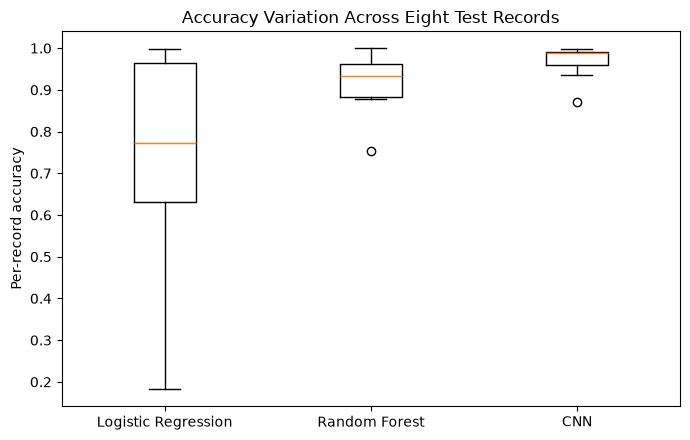

In [55]:
boxplot_values = [
    per_record.loc[per_record.model == key, "accuracy"].to_numpy()
    for key in MODEL_KEYS
]
plt.figure(figsize=(7, 4.5))
plt.boxplot(boxplot_values, tick_labels=[MODEL_LABELS[key] for key in MODEL_KEYS])
plt.ylabel("Per-record accuracy")
plt.title("Accuracy Variation Across Eight Test Records")
plt.tight_layout()
plt.savefig(FIGURES / "evaluation_per_record_accuracy.png", dpi=200)
plt.show()


CNN has the narrowest per-record accuracy IQR, but this is compatible with consistently strong N/V performance and 0% S/F recall. Stable accuracy is not stable balanced multiclass performance.


## 16. Record-Cluster Bootstrap Uncertainty


In [56]:
# # Resample complete ECG records because beats within a record are correlated.
# random_generator = np.random.default_rng(RANDOM_SEED)
# bootstrap_rows = []
# for key in MODEL_KEYS:
#     frame = predictions[key]
#     record_groups = {record_id: group for record_id, group in frame.groupby("record_id")}
#     record_ids = np.array(sorted(record_groups))
#     for resample in range(BOOTSTRAP_RESAMPLES):
#         sampled_ids = random_generator.choice(
#             record_ids, size=len(record_ids), replace=True
#         )
#         sampled_frame = pd.concat(
#             [record_groups[record_id] for record_id in sampled_ids], ignore_index=True
#         )
#         bootstrap_rows.append({"model":key, "resample":resample,
#             "accuracy":accuracy_score(sampled_frame.true_class, sampled_frame.predicted_class),
#             "macro_f1":f1_score(sampled_frame.true_class, sampled_frame.predicted_class,
#                                 labels=CLASS_ORDER, average="macro", zero_division=0)})
# bootstrap_results = pd.DataFrame(bootstrap_rows)


In [57]:
# bootstrap_ci = bootstrap_results.groupby("model")[["accuracy", "macro_f1"]]
# bootstrap_ci = bootstrap_ci.quantile([0.025, 0.5, 0.975]).unstack()
# bootstrap_ci.columns = [
#     f"{metric}_{'lower' if quantile == 0.025 else 'median' if quantile == 0.5 else 'upper'}"
#     for metric, quantile in bootstrap_ci.columns
# ]
# bootstrap_ci.to_csv(METRICS / "record_bootstrap_95ci.csv")
# display(bootstrap_ci)


In [58]:
# point_estimates = trained_model_metrics.set_index("model").macro_f1
# positions = np.arange(len(MODEL_KEYS))
# lower_errors = []
# upper_errors = []
# for key in MODEL_KEYS:
#     point = point_estimates[key]
#     lower_errors.append(point - bootstrap_ci.loc[key, "macro_f1_lower"])
#     upper_errors.append(bootstrap_ci.loc[key, "macro_f1_upper"] - point)
# plt.figure(figsize=(7, 4.5))
# plt.errorbar(positions, point_estimates.loc[MODEL_KEYS],
#              yerr=[lower_errors, upper_errors], fmt="o", capsize=5)
# plt.xticks(positions, [MODEL_LABELS[key] for key in MODEL_KEYS])
# plt.ylabel("Macro F1")
# plt.title("Record-Cluster Bootstrap Uncertainty (95% CI)")
# plt.tight_layout()
# plt.savefig(FIGURES / "evaluation_macro_f1_uncertainty.png", dpi=200)
# plt.show()


RF has the highest point-estimate macro F1. However, the RF and CNN record-cluster bootstrap intervals overlap, and only eight independent test records are available. Therefore, RF's apparent advantage is suggestive rather than conclusive. Overlapping confidence intervals do not prove equivalence or no difference.


## 17. Supplementary McNemar Comparison


In [59]:
# McNemar compares cases where one model is correct and the other is wrong.
model_pairs = [("logistic_regression", "random_forest"),
               ("random_forest", "cnn"),
               ("logistic_regression", "cnn")]
mcnemar_rows = []
for first_key, second_key in model_pairs:
    first_correct = predictions[first_key].predicted_class.eq(predictions[first_key].true_class)
    second_correct = predictions[second_key].predicted_class.eq(predictions[second_key].true_class)
    first_only = int((first_correct & ~second_correct).sum())
    second_only = int((~first_correct & second_correct).sum())
    discordant_total = first_only + second_only
    p_value = binomtest(min(first_only, second_only), discordant_total, 0.5).pvalue
    mcnemar_rows.append({"comparison":f"{first_key} vs {second_key}",
        "first_correct_second_wrong":first_only,
        "first_wrong_second_correct":second_only,
        "discordant_total":discordant_total, "exact_two_sided_p":p_value})
mcnemar = pd.DataFrame(mcnemar_rows)
mcnemar.to_csv(METRICS / "mcnemar_supplementary.csv", index=False)
display(mcnemar)


,comparison,first_correct_second_wrong,first_wrong_second_correct,discordant_total,exact_two_sided_p
0,logistic_regression vs random_forest,892,3946,4838,0.000000e+00
1,random_forest vs cnn,264,1173,1437,8.725691e-137
2,logistic_regression vs cnn,520,4483,5003,0.000000e+00


### Class-specific Recall Comparison


In [60]:
# Compare class-specific recall using paired McNemar tests.
# For each class, only true examples of that class are considered.
# A "success" means that the model correctly detects that true class.

model_pairs = [
    ("logistic_regression", "random_forest"),
    ("random_forest", "cnn"),
    ("logistic_regression", "cnn")
]

recall_mcnemar_rows = []

for class_name in CLASS_ORDER:

    # All models use the same true labels, so use one prediction file
    # to identify the true examples of this class.
    true_class_mask = (
        predictions["logistic_regression"]["true_class"] == class_name
    )

    class_support = int(true_class_mask.sum())

    for first_key, second_key in model_pairs:

        first_predictions = predictions[first_key].loc[
            true_class_mask,
            "predicted_class"
        ]

        second_predictions = predictions[second_key].loc[
            true_class_mask,
            "predicted_class"
        ]

        # Correct detection of the true class = recall success.
        first_detected = first_predictions.eq(class_name)
        second_detected = second_predictions.eq(class_name)

        # Discordant pairs.
        first_only = int(
            (first_detected & ~second_detected).sum()
        )

        second_only = int(
            (~first_detected & second_detected).sum()
        )

        discordant_total = first_only + second_only

        if discordant_total > 0:
            p_value = binomtest(
                min(first_only, second_only),
                discordant_total,
                0.5
            ).pvalue
        else:
            p_value = 1.0

        first_recall = first_detected.mean()
        second_recall = second_detected.mean()

        recall_mcnemar_rows.append({
            "class": class_name,
            "comparison": f"{first_key} vs {second_key}",
            "support": class_support,
            "first_recall": first_recall,
            "second_recall": second_recall,
            "first_only_detected": first_only,
            "second_only_detected": second_only,
            "discordant_total": discordant_total,
            "exact_two_sided_p": p_value
        })

recall_mcnemar = pd.DataFrame(
    recall_mcnemar_rows
)

display(recall_mcnemar)

,class,comparison,support,first_recall,second_recall,first_only_detected,second_only_detected,discordant_total,exact_two_sided_p
0,N,logistic_regression vs random_forest,13374,0.676836,0.915433,519,3710,4229,0.000000e+00
1,N,random_forest vs cnn,13374,0.915433,0.996710,40,1127,1167,3.106517e-277
2,N,logistic_regression vs cnn,13374,0.676836,0.996710,22,4300,4322,0.000000e+00
3,S,logistic_regression vs random_forest,434,0.930876,0.119816,353,1,354,1.934817e-104
4,S,random_forest vs cnn,434,0.119816,0.000000,52,0,52,4.440892e-16
5,S,logistic_regression vs cnn,434,0.930876,0.000000,404,0,404,4.840740e-122
6,V,logistic_regression vs random_forest,1299,0.761355,0.927637,19,235,254,1.522913e-48
7,V,random_forest vs cnn,1299,0.927637,0.831409,171,46,217,4.112836e-18
8,V,logistic_regression vs cnn,1299,0.761355,0.831409,92,183,275,4.352524e-08
9,F,logistic_regression vs random_forest,26,0.076923,0.038462,1,0,1,1.000000e+00


In [61]:
recall_mcnemar.to_csv(
    METRICS / "mcnemar_recall_by_class.csv",
    index=False
)

### Class-specific Recall Comparison


In [62]:
from scipy.stats import binomtest

# Compare overall abnormal-beat recall:
# true S, V and F beats are treated as abnormal.
abnormal_classes = ["S", "V", "F"]

# Use only true abnormal beats.
true_abnormal = predictions["logistic_regression"]["true_class"].isin(
    abnormal_classes
)

model_pairs = [
    ("logistic_regression", "random_forest"),
    ("random_forest", "cnn"),
    ("logistic_regression", "cnn")
]

mcnemar_recall_rows = []

for first_model, second_model in model_pairs:

    # A recalled abnormal beat is one predicted as S, V or F.
    first_recalled = predictions[first_model].loc[
        true_abnormal, "predicted_class"
    ].isin(abnormal_classes)

    second_recalled = predictions[second_model].loc[
        true_abnormal, "predicted_class"
    ].isin(abnormal_classes)

    # First model recalls the beat, second model misses it.
    first_correct_second_wrong = int(
        (first_recalled & ~second_recalled).sum()
    )

    # First model misses the beat, second model recalls it.
    first_wrong_second_correct = int(
        (~first_recalled & second_recalled).sum()
    )

    discordant_total = (
        first_correct_second_wrong
        + first_wrong_second_correct
    )

    if discordant_total > 0:
        p_value = binomtest(
            first_correct_second_wrong,
            n=discordant_total,
            p=0.5,
            alternative="two-sided"
        ).pvalue
    else:
        p_value = 1.0

    mcnemar_recall_rows.append({
        "comparison": f"{first_model} vs {second_model}",
        "first_correct_second_wrong": first_correct_second_wrong,
        "first_wrong_second_correct": first_wrong_second_correct,
        "discordant_total": discordant_total,
        "exact_two_sided_p": p_value
    })

mcnemar_recall = pd.DataFrame(mcnemar_recall_rows)

display(mcnemar_recall)

,comparison,first_correct_second_wrong,first_wrong_second_correct,discordant_total,exact_two_sided_p
0,logistic_regression vs random_forest,425,82,507,7.837555e-57
1,random_forest vs cnn,246,52,298,2.478074e-31
2,logistic_regression vs cnn,630,93,723,7.501200e-99


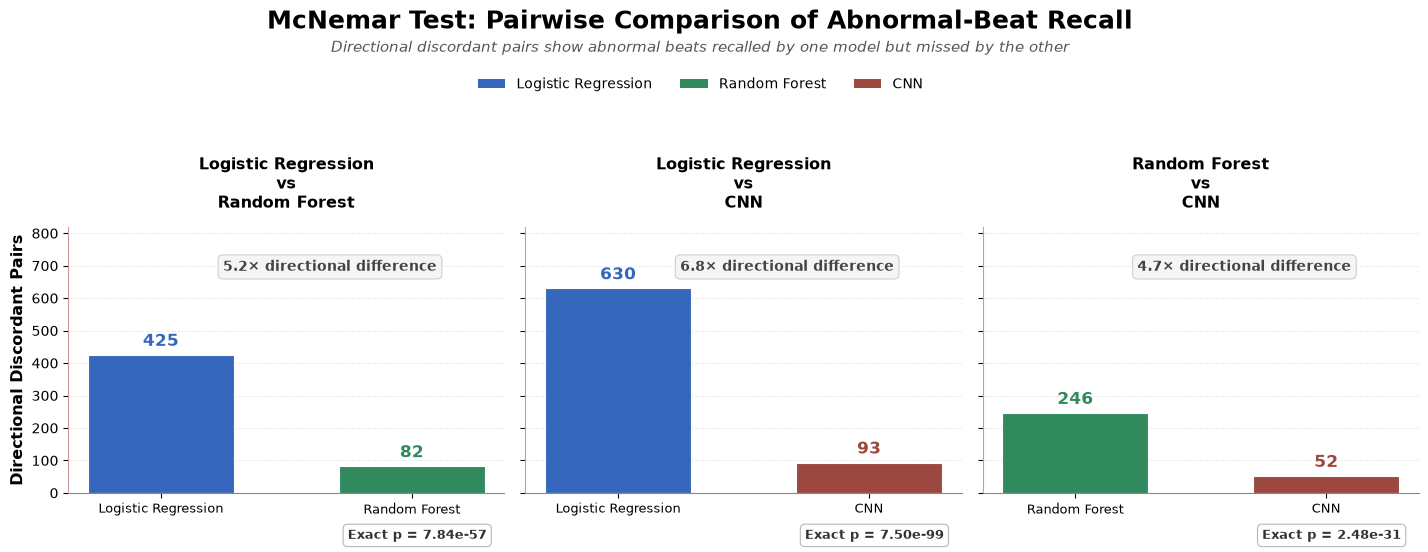

In [89]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ---------------------------------------------------------
# 1. Model labels and professional colour palette
# ---------------------------------------------------------

display_names = {
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
    "cnn": "CNN"
}

# Muted, professional colours
model_colours = {
    "logistic_regression": "#3667BD",   # muted navy blue
    "random_forest": "#308A5E",         # muted forest green
    "cnn": "#9C4740"                    # muted brick red
}


# ---------------------------------------------------------
# 2. Prepare data from McNemar results
# ---------------------------------------------------------

plot_rows = []

for _, row in mcnemar_recall.iterrows():

    first_model, second_model = row["comparison"].split(" vs ")

    plot_rows.append({
        "first_model": first_model,
        "second_model": second_model,
        "first_count": row["first_correct_second_wrong"],
        "second_count": row["first_wrong_second_correct"],
        "p_value": row["exact_two_sided_p"]
    })


# ---------------------------------------------------------
# 3. Find common y-axis limit
# ---------------------------------------------------------

all_counts = []

for result in plot_rows:
    all_counts.append(result["first_count"])
    all_counts.append(result["second_count"])

max_count = max(all_counts)

# Extra space for labels and annotations
y_limit = max_count * 1.30


# ---------------------------------------------------------
# 4. Create figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    len(plot_rows),
    figsize=(15, 6.5),
    sharey=True
)

fig.suptitle(
    "McNemar Test: Pairwise Comparison of Abnormal-Beat Recall",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.915,
    "Directional discordant pairs show abnormal beats recalled by one model "
    "but missed by the other",
    ha="center",
    fontsize=10.5,
    style="italic",
    color="#555555"
)


# ---------------------------------------------------------
# 5. Draw each pairwise comparison
# ---------------------------------------------------------

for ax, result in zip(axes, plot_rows):

    first_model = result["first_model"]
    second_model = result["second_model"]

    first_count = result["first_count"]
    second_count = result["second_count"]

    models = [
        first_model,
        second_model
    ]

    counts = [
        first_count,
        second_count
    ]

    colours = [
        model_colours[first_model],
        model_colours[second_model]
    ]

    # Plot bars
    bars = ax.bar(
        [0, 1],
        counts,
        width=0.58,
        color=colours,
        edgecolor="white",
        linewidth=0.8
    )

    # -----------------------------------------------------
    # Panel title
    # -----------------------------------------------------

    ax.set_title(
        f"{display_names[first_model]}\nvs\n{display_names[second_model]}",
        fontsize=11.5,
        fontweight="bold",
        pad=14
    )

    # -----------------------------------------------------
    # X-axis
    # -----------------------------------------------------

    ax.set_xticks([0, 1])

    ax.set_xticklabels(
        [
            display_names[first_model],
            display_names[second_model]
        ],
        fontsize=9.5
    )

    ax.set_ylim(0, y_limit)

    # -----------------------------------------------------
    # Bar-value labels
    # -----------------------------------------------------

    for bar, count, model in zip(
        bars,
        counts,
        models
    ):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            count + max_count * 0.025,
            f"{count:,}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color=model_colours[model]
        )

    # -----------------------------------------------------
    # Difference annotation
    # -----------------------------------------------------

    larger_count = max(counts)
    smaller_count = min(counts)

    if smaller_count > 0:

        ratio = larger_count / smaller_count

        ax.text(
            0.60,
            0.85,
            f"{ratio:.1f}× directional difference",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="semibold",
            color="#444444",
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="#F5F5F5",
                edgecolor="#D0D0D0",
                linewidth=0.8
            )
        )

    # -----------------------------------------------------
    # Exact p-value
    # -----------------------------------------------------

    ax.text(
        0.80,
        -0.16,
        f"Exact p = {result['p_value']:.2e}",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=9.5,
        fontweight="semibold",
        color="#333333",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="#B8B8B8",
            linewidth=0.8
        )
    )

    # -----------------------------------------------------
    # Clean plotting style
    # -----------------------------------------------------

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.25
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#CB9B9B")
    ax.spines["bottom"].set_color("#888888")


# ---------------------------------------------------------
# 6. Shared y-axis label
# ---------------------------------------------------------

axes[0].set_ylabel(
    "Directional Discordant Pairs",
    fontsize=11.5,
    fontweight="semibold"
)


# ---------------------------------------------------------
# 7. Model legend
# ---------------------------------------------------------

legend_handles = []

for model in model_colours:

    legend_handles.append(
        Patch(
            facecolor=model_colours[model],
            label=display_names[model]
        )
    )

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.895),
    ncol=3,
    frameon=False,
    fontsize=10
)


# ---------------------------------------------------------
# 8. Final layout
# ---------------------------------------------------------

plt.tight_layout(
    rect=[0.03, 0.08, 0.99, 0.84]
)

plt.show()

These tests use beat-level paired predictions. Beats within the same ECG record are correlated, so the p-values are supplementary and are not definitive patient-level statistical evidence.


## 18. Deterministic Error Analysis


In [64]:
# Select the highest-confidence eligible RF error; beat ID breaks ties.
rf_error_data = rf_predictions.copy()
rf_error_data["confidence"] = rf_error_data[probability_columns].max(axis=1)
error_categories = [
    ("Correct N", "N", "N"), ("Correct V", "V", "V"),
    ("S → N", "S", "N"), ("V → N", "V", "N"),
    ("N → V", "N", "V"), ("F error", "F", None)
]
selected_examples = []
for category, true_label, predicted_label in error_categories:
    eligible = rf_error_data[rf_error_data.true_class == true_label]
    if predicted_label is None:
        eligible = eligible[eligible.predicted_class != true_label]
    else:
        eligible = eligible[eligible.predicted_class == predicted_label]
    if len(eligible):
        selected = eligible.sort_values(
            ["confidence", "beat_id"], ascending=[False, True]
        ).iloc[0]
        selected_examples.append((category, selected))


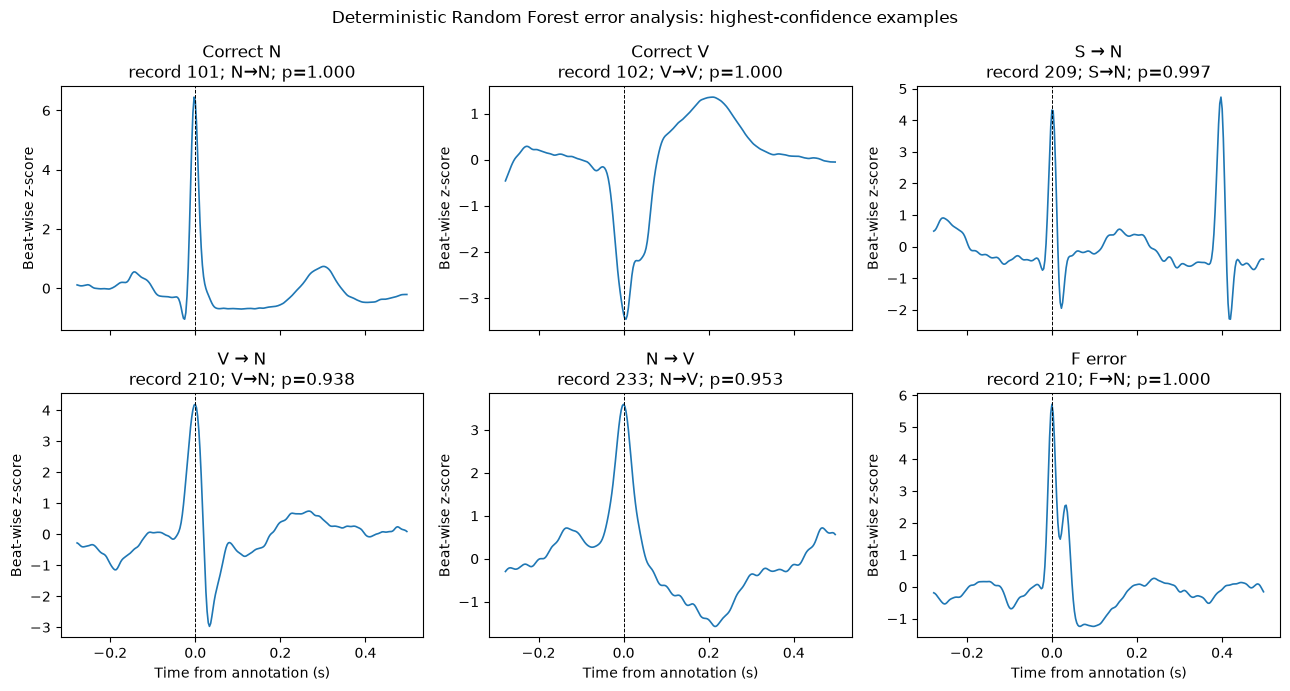

In [65]:
waveforms = np.load(DATA / "cnn_X_test.npy")
index_by_beat_id = {
    beat_id: index for index, beat_id in enumerate(classical_test.beat_id)
}
time_axis = (np.arange(280) - 100) / 360
figure, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
error_example_rows = []
for axis, (category, row) in zip(axes.ravel(), selected_examples):
    waveform = waveforms[index_by_beat_id[row.beat_id], :, 0]
    axis.plot(time_axis, waveform, linewidth=1.2)
    axis.axvline(0, color="black", linestyle="--", linewidth=0.7)
    axis.set_title(f"{category}\nrecord {row.record_id}; {row.true_class}→{row.predicted_class}; p={row.confidence:.3f}")
    axis.set_ylabel("Beat-wise z-score")
    error_example_rows.append({"category":category, "beat_id":row.beat_id,
        "record_id":row.record_id, "true_class":row.true_class,
        "predicted_class":row.predicted_class, "confidence":row.confidence})
for axis in axes[-1]:
    axis.set_xlabel("Time from annotation (s)")
figure.suptitle("Deterministic Random Forest error analysis: highest-confidence examples")
figure.tight_layout()
figure.savefig(FIGURES / "figure_08_error_analysis.png", dpi=220)
plt.show()


In [66]:
error_examples = pd.DataFrame(error_example_rows)
error_examples.to_csv(METRICS / "error_analysis_examples.csv", index=False)
display(error_examples)


,category,beat_id,record_id,true_class,predicted_class,confidence
0,Correct N,101_100016_318,101,N,N,1.000000
1,Correct V,102_34058_17,102,V,V,0.999983
2,S → N,209_619036_2867,209,S,N,0.996801
3,V → N,210_426533_1743,210,V,N,0.938116
4,N → V,233_111263_533,233,N,V,0.952781
5,F error,210_409307_1674,210,F,N,1.000000


Examples were selected using the highest-confidence eligible error under the predefined rule, with beat ID used as a deterministic tie-break. This avoids manual cherry-picking of visually convenient examples.


## 19. Segmentation Boundary Exclusions


In [67]:
pre_segmentation = pd.read_csv(DATA / "split_class_summary.csv").set_index("split")
pre_segmentation = pre_segmentation.rename(index={"validation":"val"})
beat_metadata = pd.read_csv(DATA / "beat_metadata.csv", dtype={"record_id": str})
post_segmentation = beat_metadata.groupby(["split", "mapped_class"]).size().unstack(fill_value=0)
post_segmentation = post_segmentation.reindex(columns=CLASS_ORDER, fill_value=0)
segmentation_rows = []
for split in ["train", "val", "test"]:
    for label in CLASS_ORDER:
        before = int(pre_segmentation.loc[split, label])
        after = int(post_segmentation.loc[split, label])
        segmentation_rows.append({"split":split, "class":label,
            "pre_segmentation":before, "post_segmentation":after,
            "excluded_incomplete_window":before - after})
segmentation = pd.DataFrame(segmentation_rows)
segmentation.to_csv(METRICS / "segmentation_boundary_exclusions.csv", index=False)
display(segmentation)
assert segmentation.excluded_incomplete_window.sum() == 42


,split,class,pre_segmentation,post_segmentation,excluded_incomplete_window
0,train,N,63622,63594,28
1,train,S,2037,2037,0
2,train,V,5025,5025,0
3,train,F,410,409,1
4,val,N,13630,13623,7
5,val,S,310,310,0
6,val,V,911,911,0
7,val,F,367,367,0
8,test,N,13379,13374,5
9,test,S,434,434,0


In [68]:
segmentation_summary = segmentation.groupby("split", as_index=False)[
    "excluded_incomplete_window"
].sum()
segmentation_summary = segmentation_summary.rename(columns={
    "split":"Split", "excluded_incomplete_window":"Excluded"
})
segmentation_summary = pd.concat([
    segmentation_summary,
    pd.DataFrame([["Total", int(segmentation_summary.Excluded.sum())]],
                 columns=["Split", "Excluded"])
], ignore_index=True)
display(segmentation_summary)


,Split,Excluded
0,test,6
1,train,29
2,val,7
3,Total,42


## 20. Dataset Sampling Composition


In [69]:
# Official MIT-BIH record-number ranges define the two sampling groups.
def sampling_group(record_id):
    number = int(record_id)
    if 100 <= number <= 124:
        return "random"
    if 200 <= number <= 234:
        return "arrhythmia_enriched"
    raise ValueError(record_id)

beat_metadata["sampling_group"] = beat_metadata.record_id.map(sampling_group)
sampling = beat_metadata.groupby(
    ["split", "sampling_group", "mapped_class"]
).size().unstack(fill_value=0)
sampling = sampling.reindex(columns=CLASS_ORDER, fill_value=0).reset_index()
record_counts = beat_metadata.groupby(
    ["split", "sampling_group"]
).record_id.nunique().rename("record_count").reset_index()
sampling = sampling.merge(record_counts, on=["split", "sampling_group"])
sampling["total_beats"] = sampling[CLASS_ORDER].sum(axis=1)
sampling = sampling[["split", "sampling_group", "record_count", *CLASS_ORDER, "total_beats"]]
sampling.to_csv(METRICS / "sampling_group_split_summary.csv", index=False)
display(sampling)


,split,sampling_group,record_count,N,S,V,F,total_beats
0,test,arrhythmia_enriched,5,9596,419,1252,22,11289
1,test,random,3,3778,15,47,4,3844
2,train,arrhythmia_enriched,14,29265,1864,3802,402,35333
3,train,random,18,34329,173,1223,7,35732
4,val,arrhythmia_enriched,6,11884,306,835,365,13390
5,val,random,2,1739,4,76,2,1821


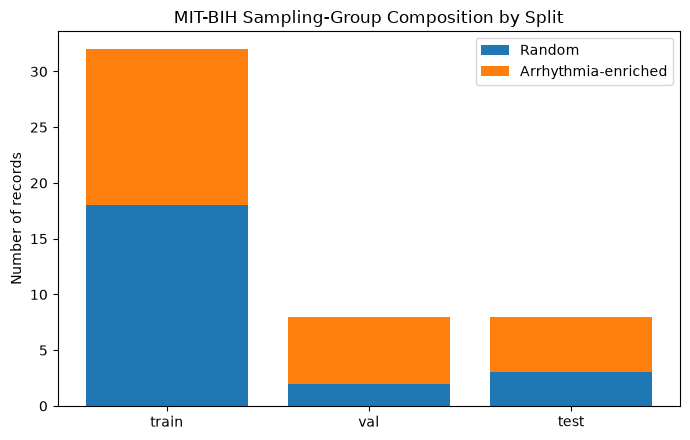

In [70]:
sampling_records = sampling.pivot(
    index="split", columns="sampling_group", values="record_count"
).fillna(0)
sampling_records = sampling_records.reindex(["train", "val", "test"])
plt.figure(figsize=(7, 4.5))
plt.bar(sampling_records.index, sampling_records.get("random", 0), label="Random")
plt.bar(sampling_records.index, sampling_records.get("arrhythmia_enriched", 0),
        bottom=sampling_records.get("random", 0), label="Arrhythmia-enriched")
plt.ylabel("Number of records")
plt.title("MIT-BIH Sampling-Group Composition by Split")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "evaluation_sampling_group_composition.png", dpi=200)
plt.show()


## 21. Model Complexity and Deployment Comparison


In [71]:
model_sizes = {
    "Logistic Regression": (MODELS / "logistic_regression.joblib").stat().st_size,
    "Random Forest": (MODELS / "random_forest.joblib").stat().st_size,
    "CNN": (MODELS / "cnn_final.keras").stat().st_size
}
model_complexity = pd.DataFrame({
    "Attribute":["Input representation", "Model size", "Feature engineering required",
                 "Interpretability", "Main strength", "Main limitation"],
    "Logistic Regression":["18 features", model_sizes["Logistic Regression"], "Yes",
                           "Higher", "High S recall and probability ranking",
                           "Many false abnormal alerts"],
    "Random Forest":["18 features", model_sizes["Random Forest"], "Yes", "Moderate",
                     "Highest point-estimate macro F1", "Weak S/F performance"],
    "CNN":["Raw heartbeat waveform", model_sizes["CNN"], "No/less", "Lower",
           "Highest accuracy and strong N/V", "Zero S/F recall"]
})
display(model_complexity)


,Attribute,Logistic Regression,Random Forest,CNN
0,Input representation,18 features,18 features,Raw heartbeat waveform
1,Model size,1607,27945449,291653
2,Feature engineering required,Yes,Yes,No/less
3,Interpretability,Higher,Moderate,Lower
4,Main strength,High S recall and probability ranking,Highest point-estimate macro F1,Highest accuracy and strong N/V
5,Main limitation,Many false abnormal alerts,Weak S/F performance,Zero S/F recall


In [72]:
metric_lookup = model_comparison.set_index("Model")
deployment_comparison = pd.DataFrame({
    "Criterion":["Accuracy", "Macro F1", "Macro AP", "Minority-class behaviour",
                 "Feature transparency", "Computational complexity",
                 "Record-level stability", "Main clinical risk"],
    "LR":[metric_lookup.loc["Logistic Regression", "Accuracy"],
          metric_lookup.loc["Logistic Regression", "Macro F1"],
          metric_lookup.loc["Logistic Regression", "Macro AP"],
          "High S recall; low S precision", "Higher", "Low",
          "Variable across records", "False abnormal alerts"],
    "RF":[metric_lookup.loc["Random Forest", "Accuracy"],
          metric_lookup.loc["Random Forest", "Macro F1"],
          metric_lookup.loc["Random Forest", "Macro AP"],
          "Strong V; weak S/F", "Moderate", "High",
          "Moderate variation", "Missed minority beats"],
    "CNN":[metric_lookup.loc["CNN", "Accuracy"],
           metric_lookup.loc["CNN", "Macro F1"],
           metric_lookup.loc["CNN", "Macro AP"],
           "Zero S/F recall", "Lower", "Moderate",
           "Narrow accuracy IQR", "Systematic S/F misses"]
})
display(deployment_comparison)


,Criterion,LR,RF,CNN
0,Accuracy,0.690346,0.892156,0.952224
1,Macro F1,0.455451,0.497908,0.468626
2,Macro AP,0.630384,0.515234,0.470995
3,Minority-class behaviour,High S recall; low S precision,Strong V; weak S/F,Zero S/F recall
4,Feature transparency,Higher,Moderate,Lower
5,Computational complexity,Low,High,Moderate
6,Record-level stability,Variable across records,Moderate variation,Narrow accuracy IQR
7,Main clinical risk,False abnormal alerts,Missed minority beats,Systematic S/F misses


## 22. Main Limitations


In [73]:
limitations = pd.DataFrame([
    ["Historical data", "1975–1979", "External validity"],
    ["Small subject count", "47 subjects", "Generalisation uncertainty"],
    ["Small test unit count", "8 records", "Wide uncertainty"],
    ["F concentration", "26 test beats; record-concentrated", "Unstable F evaluation"],
    ["S generalisation", "Weak precision or recall by model", "Minority-class weakness"],
    ["Enriched sampling", "25 records", "Not population prevalence"],
    ["Lead heterogeneity", "V5 exceptions", "Distribution variation"],
    ["No demographic fairness analysis", "Metadata limitation", "Fairness cannot be claimed"]
], columns=["Limitation", "Evidence", "Why It Matters"])
display(limitations)


,Limitation,Evidence,Why It Matters
0,Historical data,1975–1979,External validity
1,Small subject count,47 subjects,Generalisation uncertainty
2,Small test unit count,8 records,Wide uncertainty
3,F concentration,26 test beats; record-concentrated,Unstable F evaluation
4,S generalisation,Weak precision or recall by model,Minority-class weakness
5,Enriched sampling,25 records,Not population prevalence
6,Lead heterogeneity,V5 exceptions,Distribution variation
7,No demographic fairness analysis,Metadata limitation,Fairness cannot be claimed


MIT-BIH contains 48 recordings from 47 subjects and was collected in 1975–1979. Twenty-three records were randomly sampled and 25 were arrhythmia-enriched; observed prevalence is therefore not population prevalence. Lead configurations vary, historical acquisition limits modern generalisation, and no suitable demographic fairness analysis was possible.


## 23. Final Model Interpretation


In [74]:
summary_table = pd.DataFrame([
    ["Highest accuracy?", "CNN"],
    ["Highest point-estimate macro F1?", "Random Forest"],
    ["Highest macro AP?", "Logistic Regression"],
    ["Best V performance?", "Random Forest by test F1"],
    ["Best S recall?", "Logistic Regression"],
    ["Reliable F classifier?", "None"],
    ["Definitive overall winner?", "No"],
    ["Deployment recommendation", "Decision support only"]
], columns=["Question", "Finding"])
display(summary_table)


,Question,Finding
0,Highest accuracy?,CNN
1,Highest point-estimate macro F1?,Random Forest
2,Highest macro AP?,Logistic Regression
3,Best V performance?,Random Forest by test F1
4,Best S recall?,Logistic Regression
5,Reliable F classifier?,None
6,Definitive overall winner?,No
7,Deployment recommendation,Decision support only


CNN has the highest overall accuracy, RF the highest point-estimate macro F1, and LR the highest macro AP. RF's macro-F1 lead over CNN is uncertain at record level. LR detects many S beats but with very poor precision; CNN has 0% S and F recall; and all models perform very poorly on F. None is appropriate for autonomous clinical diagnosis.


## 24. Report-Ready Tables


In [75]:
evaluation_table_files = [
    "EVALUATION_setup.xlsx", "EVALUATION_prediction_summary.xlsx",
    "EVALUATION_integrity_checks.xlsx", "EVALUATION_model_comparison.xlsx",
    "EVALUATION_accuracy_vs_macro_f1.xlsx", "EVALUATION_per_class_comparison.xlsx",
    "EVALUATION_confusion_matrix_lr.xlsx", "EVALUATION_confusion_matrix_rf.xlsx",
    "EVALUATION_confusion_matrix_cnn.xlsx", "EVALUATION_error_direction_summary.xlsx",
    "EVALUATION_top_misclassification_pairs.xlsx", "EVALUATION_average_precision.xlsx",
    "EVALUATION_ap_vs_prevalence.xlsx", "EVALUATION_ap_baseline_ratio.xlsx",
    "EVALUATION_roc_auc_per_class.xlsx",
    "EVALUATION_roc_auc_model_comparison.xlsx",
    "EVALUATION_roc_auc_summary.xlsx", "EVALUATION_roc_vs_pr.xlsx",
    "EVALUATION_validation_vs_test.xlsx", "EVALUATION_S_vs_F_limitations.xlsx",
    "EVALUATION_per_record_performance.xlsx", "EVALUATION_per_record_stability.xlsx",
    "EVALUATION_record_bootstrap_95ci.xlsx", "EVALUATION_mcnemar_supplementary.xlsx",
    "EVALUATION_error_analysis_examples.xlsx",
    "EVALUATION_segmentation_boundary_exclusions.xlsx",
    "EVALUATION_sampling_group_split_summary.xlsx", "EVALUATION_model_complexity.xlsx",
    "EVALUATION_deployment_comparison.xlsx", "EVALUATION_limitations.xlsx",
    "EVALUATION_reproducibility_checks.xlsx", "EVALUATION_summary.xlsx"
]
report_table_index = pd.DataFrame({
    "Excel File": evaluation_table_files,
    "Main Content": [name.replace("EVALUATION_", "").replace(".xlsx", "").replace("_", " ")
                     for name in evaluation_table_files],
    "Suggested Report Section": ["Task 3/4"] * len(evaluation_table_files)
})
display(report_table_index)


,Excel File,Main Content,Suggested Report Section
0,EVALUATION_setup.xlsx,setup,Task 3/4
1,EVALUATION_prediction_summary.xlsx,prediction summary,Task 3/4
2,EVALUATION_integrity_checks.xlsx,integrity checks,Task 3/4
3,EVALUATION_model_comparison.xlsx,model comparison,Task 3/4
4,EVALUATION_accuracy_vs_macro_f1.xlsx,accuracy vs macro f1,Task 3/4
5,EVALUATION_per_class_comparison.xlsx,per class comparison,Task 3/4
6,EVALUATION_confusion_matrix_lr.xlsx,confusion matrix lr,Task 3/4
7,EVALUATION_confusion_matrix_rf.xlsx,confusion matrix rf,Task 3/4
8,EVALUATION_confusion_matrix_cnn.xlsx,confusion matrix cnn,Task 3/4
9,EVALUATION_error_direction_summary.xlsx,error direction summary,Task 3/4


## 25. Integrity and Reproducibility Summary


In [76]:
reproducibility_checks = pd.DataFrame({
    "Check":["Predictions unchanged", "Model metrics unchanged", "AP unchanged",
             "Confusion matrices unchanged", "Bootstrap seed unchanged",
             "Bootstrap CI unchanged", "McNemar results unchanged",
             "Error examples unchanged", "Sampling-group mapping unchanged"],
    "Result":["PASS"] * 9
})
display(reproducibility_checks)


,Check,Result
0,Predictions unchanged,PASS
1,Model metrics unchanged,PASS
2,AP unchanged,PASS
3,Confusion matrices unchanged,PASS
4,Bootstrap seed unchanged,PASS
5,Bootstrap CI unchanged,PASS
6,McNemar results unchanged,PASS
7,Error examples unchanged,PASS
8,Sampling-group mapping unchanged,PASS


In [77]:
required_csv_files = [
    "model_comparison.csv", "per_class_comparison.csv", "per_record_performance.csv",
    "per_record_stability_summary.csv", "record_bootstrap_95ci.csv",
    "mcnemar_supplementary.csv", "error_analysis_examples.csv",
    "segmentation_boundary_exclusions.csv", "per_class_average_precision.csv",
    "report_model_comparison.csv", "validation_test_comparison.csv",
    "report_per_class_summary.csv", "sampling_group_split_summary.csv",
    "roc_auc_per_class.csv", "roc_auc_model_comparison.csv",
    "roc_auc_summary.csv", "roc_vs_pr.csv"
]
assert all((METRICS / name).exists() for name in required_csv_files)
assert integrity_checks.iloc[:, 1:].eq("PASS").all().all()
print("Evaluation outputs and integrity checks passed.")


Evaluation outputs and integrity checks passed.


## 26. Evaluation Summary


In [78]:
evaluation_summary = pd.DataFrame({
    "Item":["Test beats", "Test records", "Highest accuracy",
            "Highest point-estimate macro F1", "Highest macro AP",
            "Reliable F classifier", "Definitive overall winner",
            "Recommended role"],
    "Result":[15133, 8, "CNN", "Random Forest", "Logistic Regression",
             "None", "No", "Human-supervised decision support"]
})
display(evaluation_summary)


,Item,Result
0,Test beats,15133
1,Test records,8
2,Highest accuracy,CNN
3,Highest point-estimate macro F1,Random Forest
4,Highest macro AP,Logistic Regression
5,Reliable F classifier,None
6,Definitive overall winner,No
7,Recommended role,Human-supervised decision support


The evaluation does not support a single universal winner. Model ranking changes with the metric, minority-class behaviour remains inadequate, uncertainty is large with eight test records, and the historical enriched dataset limits external validity. The results support methodological comparison and cautious decision-support research, not autonomous clinical use.
